In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")

# Exploring the sudden step-change in measured loads for Nitelva

## 1. Read data

Just consider data since 2010.

In [2]:
df = pd.read_excel(
    "../data/cleaned_concs_waterbodies.xlsx",
    sheet_name="cleaned_chem",
)

df = (
    df.query(
        "(waterbody_id == '002-3891-R') and "
        "(sample_date >= '2010-01-01') and "
        "(sample_date < '2025-01-01')"
    )
    .sort_values("sample_date")
    .set_index("sample_date")[["TOTP_µg/l"]]
    .dropna()
)

q_df = (
    pd.read_excel(
        "../data/nve_data.xlsx",
        sheet_name="gts-api",
    )
    .query("date >= '2010-01-01'")
    .set_index("date")[["002-30586"]]
)

q_df.columns = ["flow_m3/s"]

df = df.join(q_df, how="left")

df.head()

,TOTP_µg/l,flow_m3/s
sample_date,,
2010-01-06,17.0,2.401129
2010-04-21,48.0,15.348681
2010-04-28,32.0,14.089711
2010-05-05,16.0,13.882046
2010-05-11,24.0,8.258399


(0.0, 200.0)

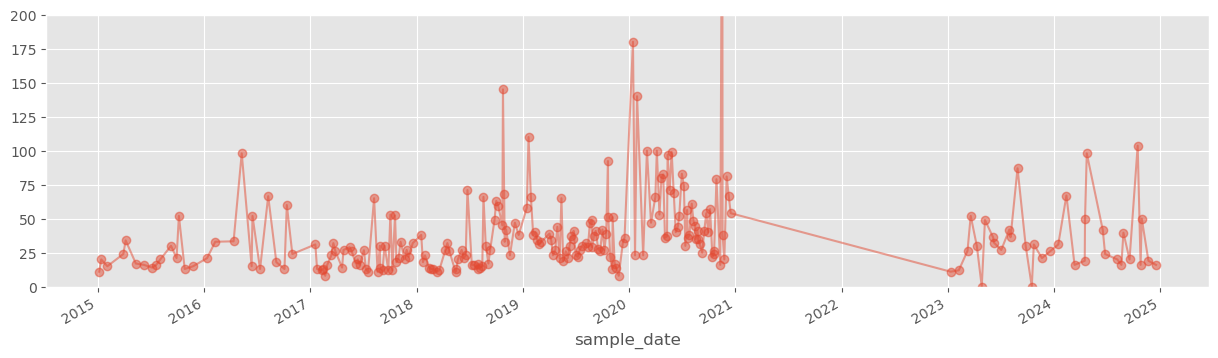

In [3]:
ax = df[df.index >= "2015-01-01"]["TOTP_µg/l"].plot(
    marker="o", alpha=0.5, figsize=(15, 4)
)
ax.set_ylim(0, 200)

## 2. Summary statistics

### 2.1. Flow percentile of each sample relative to the full daily flow record

In [4]:
q_sorted = np.sort(q_df["flow_m3/s"].dropna().values)

df["flow_percentile"] = np.searchsorted(
    q_sorted,
    df["flow_m3/s"].values,
    side="right",
) / len(q_sorted)

df["period"] = np.where(
    df.index.year < 2020,
    "Pre-2020",
    "Post-2020",
)

print("\nFlow percentiles:")
print(df.groupby("period")["flow_percentile"].describe().round(3))


Flow percentiles:
           count   mean    std    min    25%    50%    75%    max
period                                                           
Post-2020   84.0  0.636  0.243  0.114  0.468  0.646  0.835  0.997
Pre-2020   320.0  0.456  0.281  0.001  0.198  0.462  0.679  0.996


### 2.2. Annual flow-weighted concentration

In [5]:
annual = (
    df.assign(CQ=df["TOTP_µg/l"] * df["flow_m3/s"])
    .groupby(df.index.year)
    .agg(
        mean_C=("TOTP_µg/l", "mean"),
        flow_weighted_num=("CQ", "sum"),
        flow_sum=("flow_m3/s", "sum"),
        n_samples=("TOTP_µg/l", "size"),
    )
)

annual["flow_weighted_C"] = annual["flow_weighted_num"] / annual["flow_sum"]

annual["fw_factor"] = annual["flow_weighted_C"] / annual["mean_C"]

print("\nAnnual summary:")
print(
    annual[
        [
            "mean_C",
            "flow_weighted_C",
            "fw_factor",
            "n_samples",
        ]
    ].round(2)
)


Annual summary:
             mean_C  flow_weighted_C  fw_factor  n_samples
sample_date                                               
2010          29.09            29.91       1.03         34
2011          35.44            35.47       1.00         48
2012          35.48            36.65       1.03         50
2013          24.48            30.04       1.23         38
2015          21.20            22.27       1.05         15
2016          37.24            44.46       1.19         12
2017          23.28            24.80       1.07         36
2018          32.21            29.41       0.91         39
2019          36.17            37.68       1.04         48
2020          62.17            82.93       1.33         49
2023          30.52            41.32       1.35         18
2024          38.06            41.07       1.08         17


### 2.3. How much does the largest sample contribute?

In [6]:
def largest_contribution(g):
    cq = g["TOTP_µg/l"] * g["flow_m3/s"]
    return 100 * cq.max() / cq.sum()


largest_pct = (
    df.groupby(df.index.year).apply(largest_contribution).rename("largest_sample_pct")
)

print("\nLargest sample contribution (% of annual CQ):")
print(largest_pct.round(1))


Largest sample contribution (% of annual CQ):
sample_date
2010    13.1
2011    11.0
2012    18.8
2013    18.9
2015    15.6
2016    30.9
2017    12.7
2018    19.4
2019    14.3
2020    33.7
2023    48.5
2024    23.6
Name: largest_sample_pct, dtype: float64


## 3. Plots

### 3.1. Sampled flow percentiles

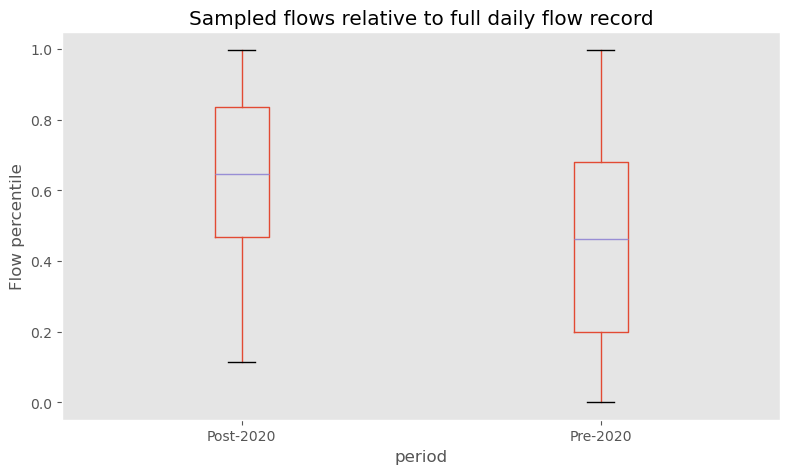

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(
    column="flow_percentile",
    by="period",
    ax=ax,
    grid=False,
)

ax.set_ylabel("Flow percentile")
ax.set_title("Sampled flows relative to full daily flow record")
plt.suptitle("")

plt.tight_layout()

### 3.2. Arithmetic vs flow-weighted concentration

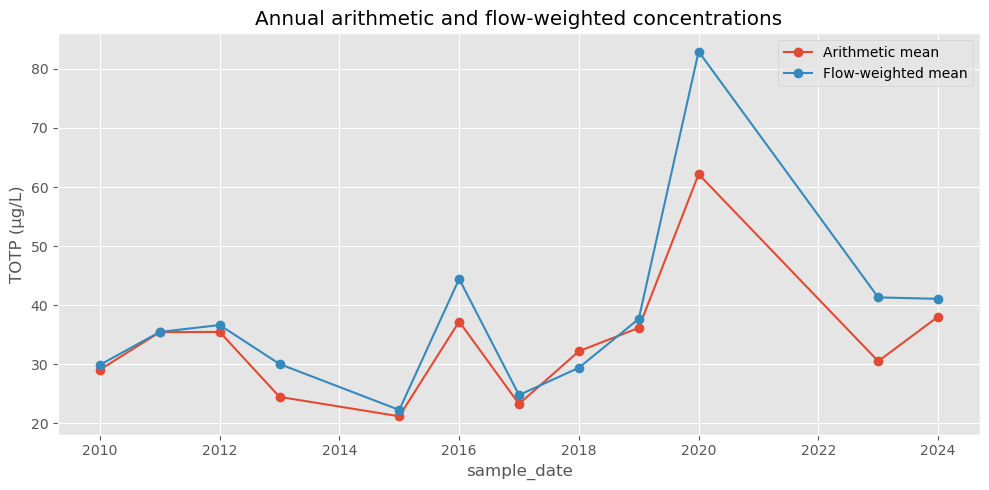

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

annual["mean_C"].plot(
    marker="o",
    label="Arithmetic mean",
    ax=ax,
)

annual["flow_weighted_C"].plot(
    marker="o",
    label="Flow-weighted mean",
    ax=ax,
)

ax.set_ylabel("TOTP (µg/L)")
ax.set_title("Annual arithmetic and flow-weighted concentrations")
ax.legend()

plt.tight_layout()

### 3.3. Dominance of largest sample

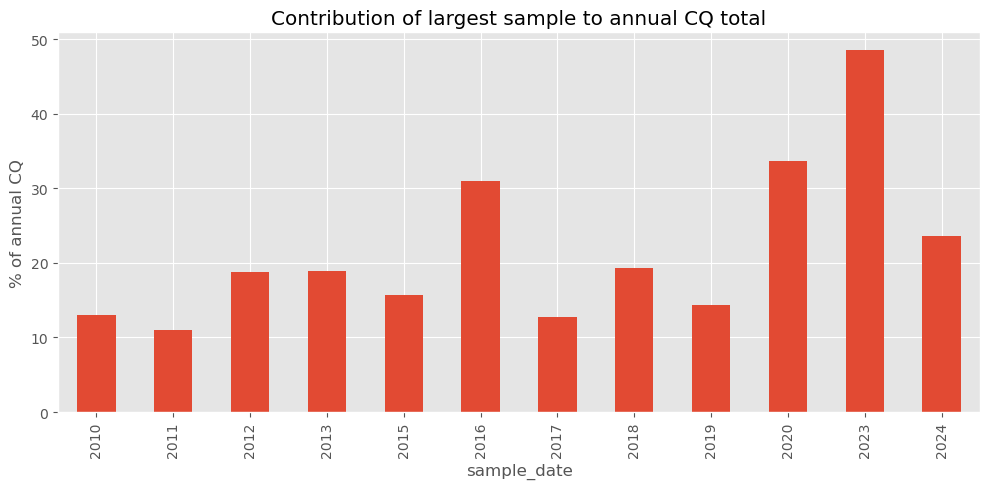

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

largest_pct.plot(
    kind="bar",
    ax=ax,
)

ax.set_ylabel("% of annual CQ")
ax.set_title("Contribution of largest sample to annual CQ total")

plt.tight_layout()